# **Bias & Trustworthiness in Hate Speech Detection**
**An Explainability Analysis Using SHAP and Human Rationales**


This project analyzes bias and trustworthiness in hate speech detection using the HateXplain dataset. Four models [Majority Class, TF-IDF, FastText, DistilBERT] are compared, and SHAP is used to evaluate whether the model relies on the same words as human annotators.

In [ ]:
!pip install datasets shap transformers

In [ ]:
import json
import urllib.request

In [ ]:
url = "https://raw.githubusercontent.com/hate-alert/HateXplain/master/Data/dataset.json"
urllib.request.urlretrieve(url, "dataset.json")

('dataset.json', <http.client.HTTPMessage at 0x7b3cd9949190>)

# 1. Dataset Exploration & Bias Analysis

In [ ]:
with open ("dataset.json", "r") as f:
  data = json.load(f)

print(f"Total Posts: {len(data)}")

Total Posts: 20148


In [ ]:
first_key = list(data.keys())[0]
print(json.dumps(data[first_key], indent=2))

{
  "post_id": "1179055004553900032_twitter",
  "annotators": [
    {
      "label": "normal",
      "annotator_id": 1,
      "target": [
        "None"
      ]
    },
    {
      "label": "normal",
      "annotator_id": 2,
      "target": [
        "None"
      ]
    },
    {
      "label": "normal",
      "annotator_id": 3,
      "target": [
        "None"
      ]
    }
  ],
  "rationales": [],
  "post_tokens": [
    "i",
    "dont",
    "think",
    "im",
    "getting",
    "my",
    "baby",
    "them",
    "white",
    "9",
    "he",
    "has",
    "two",
    "white",
    "j",
    "and",
    "nikes",
    "not",
    "even",
    "touched"
  ]
}


In [ ]:
#lets find all labels
all_labels = set()
for post in data.values():
  for i in post["annotators"]:
    all_labels.add(i["label"])
print((all_labels))

{'normal', 'offensive', 'hatespeech'}


In [ ]:
#post example
for key, post in data.items():
  labels = [i["label"] for i in post["annotators"]]
  if labels.count("hatespeech") >= 2:
    print(json.dumps(post, indent=2))
    break

{
  "post_id": "1179088797964763136_twitter",
  "annotators": [
    {
      "label": "hatespeech",
      "annotator_id": 1,
      "target": [
        "Asian"
      ]
    },
    {
      "label": "offensive",
      "annotator_id": 4,
      "target": [
        "Asian"
      ]
    },
    {
      "label": "hatespeech",
      "annotator_id": 3,
      "target": [
        "Asian"
      ]
    }
  ],
  "rationales": [
    [
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      1,
      1,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0
    ],
    [
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      1,
      1,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0
    ],
    [
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,


In [ ]:
import pandas as pd
from collections import Counter

rows = []
for key, post in data.items():
    annotator_labels = [a["label"] for a in post["annotators"]] #get labels from 3 annotators
    majority_label = Counter(annotator_labels).most_common(1)[0][0] #final label with majority vote
    text = " ".join(post["post_tokens"]) #join tokens into full text

    rows.append({
        "post_id": post["post_id"],
        "text": text,
        "label": majority_label
    })

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(20148, 3)


,post_id,text,label
0,1179055004553900032_twitter,i dont think im getting my baby them white 9 h...,normal
1,1179063826874032128_twitter,we cannot continue calling ourselves feminists...,normal
2,1178793830532956161_twitter,nawt yall niggers ignoring me,normal
3,1179088797964763136_twitter,<user> i am bit confused coz chinese ppl can n...,hatespeech
4,1179085312976445440_twitter,this bitch in whataburger eating a burger with...,hatespeech


**Note:**
Row 2 contains a racial slur but is labeled as 'normal'.
This is a key example for annotation bias discussion.

In [ ]:
#lets discover label distribution
print(df["label"].value_counts())
print()
print(df["label"].value_counts(normalize=True).round(3) * 100)

label
normal        8153
hatespeech    6234
offensive     5761
Name: count, dtype: int64

label
normal        40.5
hatespeech    30.9
offensive     28.6
Name: proportion, dtype: float64


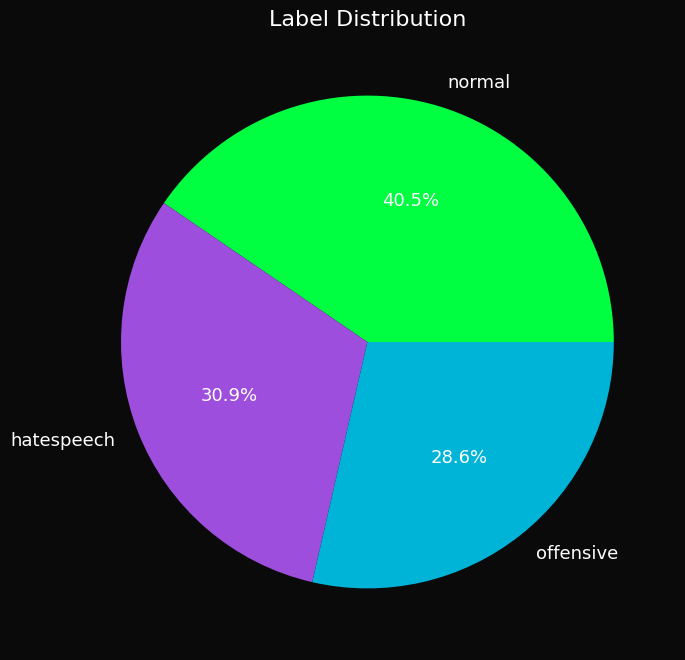

In [ ]:
import matplotlib.pyplot as plt

colors = {"normal": "#00ff41", "hatespeech": "#9d4edd", "offensive": "#00b4d8"}
counts = df["label"].value_counts()

fig, ax = plt.subplots(figsize=(8, 8), facecolor="#0a0a0a")
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=counts.index,
    colors=[colors[label] for label in counts.index],
    autopct="%1.1f%%",
    textprops={"color": "white", "fontsize": 13}
)
ax.set_title("Label Distribution", color="white", fontsize=16)
fig.patch.set_facecolor("#0a0a0a")
plt.show()

In [ ]:
#platform distribution
df["platform"] = df["post_id"].apply(lambda x: "twitter" if "twitter" in x else "gab")
print(df["platform"].value_counts())

platform
gab        11121
twitter     9027
Name: count, dtype: int64


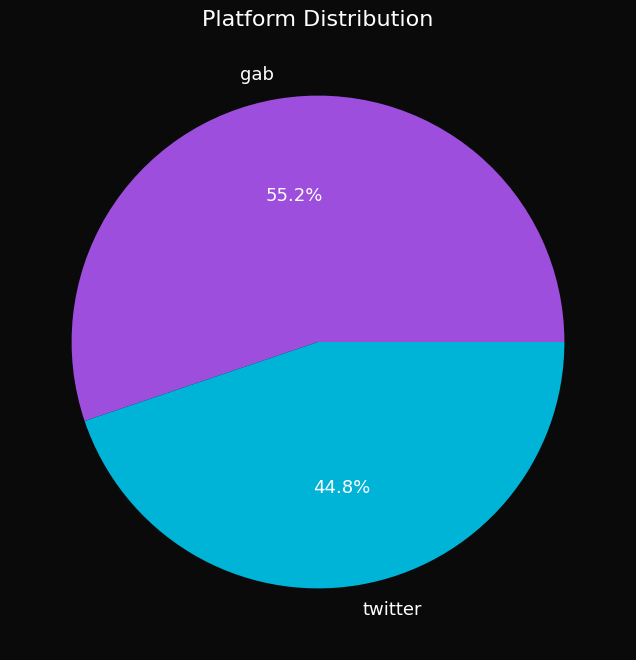

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8), facecolor="#0a0a0a")
platform_counts = df["platform"].value_counts()
colors_platform = {"gab": "#9d4edd", "twitter": "#00b4d8"}

wedges, texts, autotexts = ax.pie(
    platform_counts.values,
    labels=platform_counts.index,
    colors=[colors_platform[p] for p in platform_counts.index],
    autopct="%1.1f%%",
    textprops={"color": "white", "fontsize": 13}
)
ax.set_title("Platform Distribution", color="white", fontsize=16)
fig.patch.set_facecolor("#0a0a0a")
plt.show()

This is expected.
Gab is an **unmoderated** platform, while Twitter has content moderation policies.

In [ ]:
#platform vs label dist.
print(pd.crosstab(df["platform"], df["label"], normalize="index").round(3) * 100)

label     hatespeech  normal  offensive
platform                               
gab             49.0    20.7       30.2
twitter          8.7    64.8       26.6


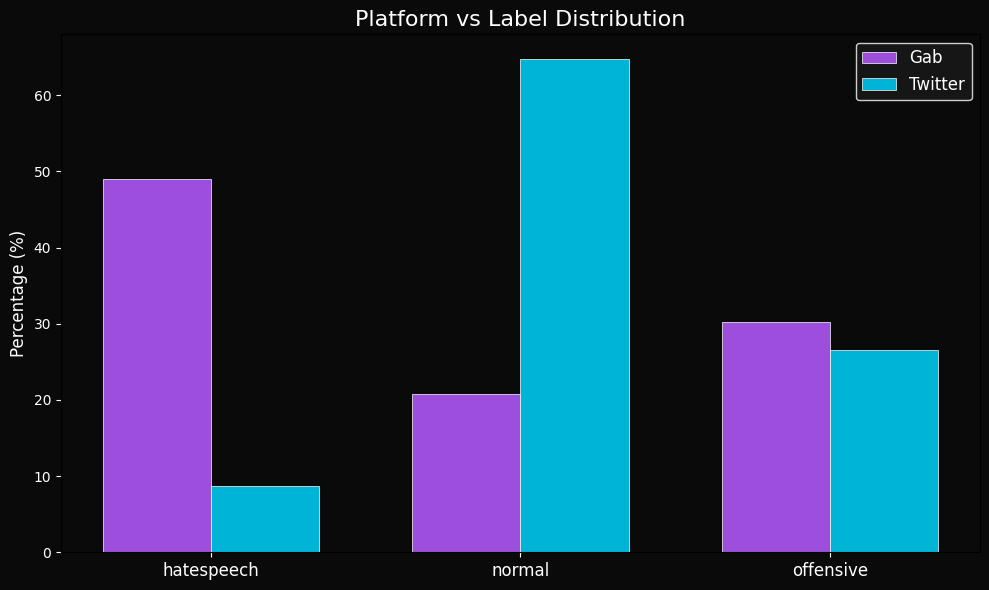

In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#0a0a0a")
ax.set_facecolor("#0a0a0a")

ct = pd.crosstab(df["platform"], df["label"], normalize="index") * 100
x = np.arange(len(ct.columns))
width = 0.35

gab_color = "#9d4edd"
twitter_color = "#00b4d8"

ax.bar(x - width/2, ct.loc["gab"], width, label="Gab", color=gab_color, edgecolor="white", linewidth=0.5)
ax.bar(x + width/2, ct.loc["twitter"], width, label="Twitter", color=twitter_color, edgecolor="white", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(ct.columns, color="white", fontsize=12)
ax.set_ylabel("Percentage (%)", color="white", fontsize=12)
ax.set_title("Platform vs Label Distribution", color="white", fontsize=16)
ax.legend(facecolor="#1a1a1a", edgecolor="white", labelcolor="white", fontsize=12)
ax.tick_params(colors="white")
plt.tight_layout()
plt.show()

In [ ]:
#word count of each post
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

print(df["word_count"].describe())

count    20148.000000
mean        23.570528
std         13.824505
min          2.000000
25%         12.000000
50%         21.000000
75%         34.000000
max        165.000000
Name: word_count, dtype: float64


In [ ]:
print(df.groupby("label")["word_count"].mean().round(1))

label
hatespeech    24.7
normal        23.5
offensive     22.5
Name: word_count, dtype: float64


In [ ]:
#most frequently used words -- which words are dominant in each class??

from collections import Counter

for label in ["hatespeech", "offensive", "normal"]:
    words = " ".join(df[df["label"] == label]["text"]).split()
    #filter out short and meaningless words
    words = [w for w in words if len(w) > 2]
    common = Counter(words).most_common(10)
    print(f"\n{label.upper()}:")
    for word, count in common:
        print(f"  {word}: {count}")


HATESPEECH:
  the: 5567
  and: 3064
  you: 2376
  are: 1892
  not: 1807
  nigger: 1721
  that: 1707
  they: 1200
  for: 1179
  white: 1053

OFFENSIVE:
  the: 4463
  and: 2506
  you: 2141
  <user>: 1679
  are: 1668
  not: 1536
  that: 1506
  they: 1060
  for: 963
  white: 832

NORMAL:
  the: 5998
  <user>: 4876
  and: 3934
  you: 2584
  not: 2360
  that: 2080
  white: 1983
  are: 1966
  for: 1558
  they: 1439


In [ ]:
#inter-annotator agreement: do all 3 annotators agree?
agreement_count = 0
for key, post in data.items():
    labels = [a["label"] for a in post["annotators"]]
    if len(set(labels)) == 1:
        agreement_count += 1

total = len(data)
print(f"Full agreement: {agreement_count}/{total} ({agreement_count/total*100:.1f}%)")
print(f"Disagreement: {total - agreement_count}/{total} ({(total-agreement_count)/total*100:.1f}%)")

Full agreement: 9845/20148 (48.9%)
Disagreement: 10303/20148 (51.1%)


**Key Finding:**
More than half of the posts (51.1%) have annotator disagreement.

This is concrete evidence of annotation bias, showing that the definition of "hate speech" is inherently subjective.

In [ ]:
#disagreement breakdown by final label
from collections import Counter

disagree_labels = []
agree_labels = []
for key, post in data.items():
    labels = [a["label"] for a in post["annotators"]]
    majority = Counter(labels).most_common(1)[0][0]
    if len(set(labels)) == 1:
        agree_labels.append(majority)
    else:
        disagree_labels.append(majority)

print("Full agreement by class:")
for label, count in Counter(agree_labels).most_common():
    print(f"  {label}: {count}")

print("\nDisagreement by class:")
for label, count in Counter(disagree_labels).most_common():
    print(f"  {label}: {count}")

Full agreement by class:
  normal: 5124
  hatespeech: 2960
  offensive: 1761

Disagreement by class:
  offensive: 4000
  hatespeech: 3274
  normal: 3029


**Disagreement is highest for the "offensive" class** (4,000 out of 5,761 posts).

This suggests that the boundary between offensive and hate speech is the most ambiguous for annotators, making it the hardest class to classify reliably.

In [ ]:
#target community distribution
targets = []
for key, post in data.items():
    labels = [a["label"] for a in post["annotators"]]
    majority = Counter(labels).most_common(1)[0][0]
    if majority != "normal":
        for a in post["annotators"]:
            for t in a["target"]:
                if t != "None":
                    targets.append(t)

target_counts = Counter(targets).most_common(15)
print("Top 15 Target Communities:")
for target, count in target_counts:
    print(f"  {target}: {count}")

Top 15 Target Communities:
  African: 8983
  Islam: 5546
  Jewish: 5437
  Women: 4680
  Homosexual: 4518
  Other: 3560
  Arab: 2589
  Refugee: 2004
  Caucasian: 1602
  Hispanic: 1149
  Men: 1143
  Asian: 1021
  Disability: 195
  Christian: 190
  Minority: 175


**Target community distribution is highly imbalanced.**

African (8,983) is the most targeted, while Disability (195) and Christian (190) are underrepresented.

The model may perform better on well-represented groups and fail on underrepresented ones.

# 2. Text Preprocessing

In [ ]:
#text preprocessing
import re

def preprocess(text):
    text = text.lower()
    text = re.sub(r'<user>', '', text)  #remove user mentions
    text = re.sub(r'http\S+', '', text)  #remove urls
    text = re.sub(r'[^a-zA-Z\s]', '', text)  #keep only letters
    text = text.strip()
    return text

df["clean_text"] = df["text"].apply(preprocess)
print(df[["text", "clean_text"]].head())

                                                text  \
0  i dont think im getting my baby them white 9 h...   
1  we cannot continue calling ourselves feminists...   
2                      nawt yall niggers ignoring me   
3  <user> i am bit confused coz chinese ppl can n...   
4  this bitch in whataburger eating a burger with...   

                                          clean_text  
0  i dont think im getting my baby them white  he...  
1  we cannot continue calling ourselves feminists...  
2                      nawt yall niggers ignoring me  
3  i am bit confused coz chinese ppl can not acce...  
4  this bitch in whataburger eating a burger with...  


Preprocessing applied: <user> tags removed, text lowercased, URLs and special characters cleaned. The model will now focus on actual word content.

In [ ]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"\nTrain distribution:\n{y_train.value_counts(normalize=True).round(3) * 100}")

Train: 16118, Test: 4030

Train distribution:
label
normal        40.5
hatespeech    30.9
offensive     28.6
Name: proportion, dtype: float64


# 3. Baseline 0: Majority Class Predictor

In [ ]:
from sklearn.metrics import classification_report
from sklearn.dummy import DummyClassifier

#model 0: majority class baseline (always predicts "normal")
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("=== Majority Class Baseline ===")
print(classification_report(y_test, y_pred_dummy))

=== Majority Class Baseline ===
              precision    recall  f1-score   support

  hatespeech       0.00      0.00      0.00      1247
      normal       0.40      1.00      0.58      1631
   offensive       0.00      0.00      0.00      1152

    accuracy                           0.40      4030
   macro avg       0.13      0.33      0.19      4030
weighted avg       0.16      0.40      0.23      4030



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Majority class baseline:**

40% accuracy, 0.19 macro-F1.

Always predicts "normal".

This is the minimum bar that any real model must beat.

# 4. Baseline 1: TF-IDF + Logistic Regression

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

#model 1: TF-IDF + Logistic Regression
tfidf = TfidfVectorizer(max_features=10000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

print("=== TF-IDF + Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

=== TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

  hatespeech       0.72      0.69      0.70      1247
      normal       0.62      0.75      0.68      1631
   offensive       0.52      0.39      0.44      1152

    accuracy                           0.63      4030
   macro avg       0.62      0.61      0.61      4030
weighted avg       0.62      0.63      0.62      4030



TF-IDF + LR: 63% accuracy, 0.61 macro-F1.

Major improvement over baseline.

Offensive class has the lowest F1(0.44), consistent with the high annotator disagreement found in bias analysis.

# 5. Embedding-Based Model: FastText + Logistic Regression

In [ ]:
import numpy as np

#download FastText embeddings
import urllib.request
import os

if not os.path.exists("wiki-news-300d-1M.vec"):
    print("Downloading FastText embeddings (this may take a few minutes)...")
    urllib.request.urlretrieve(
        "https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M.vec.zip",
        "fasttext.zip"
    )
    import zipfile
    with zipfile.ZipFile("fasttext.zip", "r") as z:
        z.extractall(".")
    print("Done!")

#load embeddings
print("Loading embeddings...")
embeddings = {}
with open("wiki-news-300d-1M.vec", "r", encoding="utf-8") as f:
    next(f)  #skip header
    for line in f:
        parts = line.rstrip().split(" ")
        embeddings[parts[0]] = np.array(parts[1:], dtype=np.float32)
print(f"Loaded {len(embeddings)} word vectors")

Done!
Loading embeddings...
Loaded 999994 word vectors


In [ ]:
#convert each post to average FastText embedding
def text_to_vec(text):
    words = text.split()
    vecs = [embeddings[w] for w in words if w in embeddings]
    if len(vecs) == 0:
        return np.zeros(300)
    return np.mean(vecs, axis=0)

X_train_ft = np.array([text_to_vec(t) for t in X_train])
X_test_ft = np.array([text_to_vec(t) for t in X_test])

#model 2: FastText + Logistic Regression
lr_ft = LogisticRegression(max_iter=1000, random_state=42)
lr_ft.fit(X_train_ft, y_train)
y_pred_ft = lr_ft.predict(X_test_ft)

print("=== FastText + Logistic Regression ===")
print(classification_report(y_test, y_pred_ft))

=== FastText + Logistic Regression ===
              precision    recall  f1-score   support

  hatespeech       0.64      0.58      0.61      1247
      normal       0.56      0.78      0.65      1631
   offensive       0.54      0.30      0.39      1152

    accuracy                           0.58      4030
   macro avg       0.58      0.55      0.55      4030
weighted avg       0.58      0.58      0.56      4030



FastText + LR: 58% accuracy, 0.55 macro-F1.

Surprisingly underperforms TF-IDF.

This suggests hate speech detection relies more on specific keywords than semantic similarity.

Offensive class remains the weakest (0.39 F1).

# 6. Transformer Model: DistilBERT Fine-Tuning

In [ ]:
!pip install transformers accelerate -q

from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset

#prepare label encoding
label2id = {"hatespeech": 0, "normal": 1, "offensive": 2}
id2label = {v: k for k, v in label2id.items()}

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

class HateDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=128)
        self.labels = [label2id[l] for l in labels]

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = HateDataset(X_train, y_train)
test_dataset = HateDataset(X_test, y_test)

print("Datasets ready!")
print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Datasets ready!
Train: 16118, Test: 4030


In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
import torch

label2id = {"hatespeech": 0, "normal": 1, "offensive": 2}
id2label = {v: k for k, v in label2id.items()}

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()
print("Training complete!")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.815725,0.766129
2,0.636189,0.804906
3,0.453129,0.874215


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete!


In [ ]:
#DistilBERT evaluation
y_pred_bert = trainer.predict(test_dataset).predictions.argmax(-1)
y_pred_bert_labels = [id2label[p] for p in y_pred_bert]

print("=== DistilBERT Fine-tuned ===")
print(classification_report(y_test, y_pred_bert_labels))

=== DistilBERT Fine-tuned ===
              precision    recall  f1-score   support

  hatespeech       0.68      0.79      0.73      1247
      normal       0.68      0.76      0.72      1631
   offensive       0.59      0.38      0.46      1152

    accuracy                           0.66      4030
   macro avg       0.65      0.64      0.64      4030
weighted avg       0.65      0.66      0.65      4030



**DistilBERT achieves the best performance(66% accuracy, 0.64 macro-F1)** but the gap over TF-IDF is modest (+3%).

The offensive class remains the weakest across all models (0.49 F1), consistent with high annotator disagreement.

This suggests the challenge is partly in the data, not just the model.

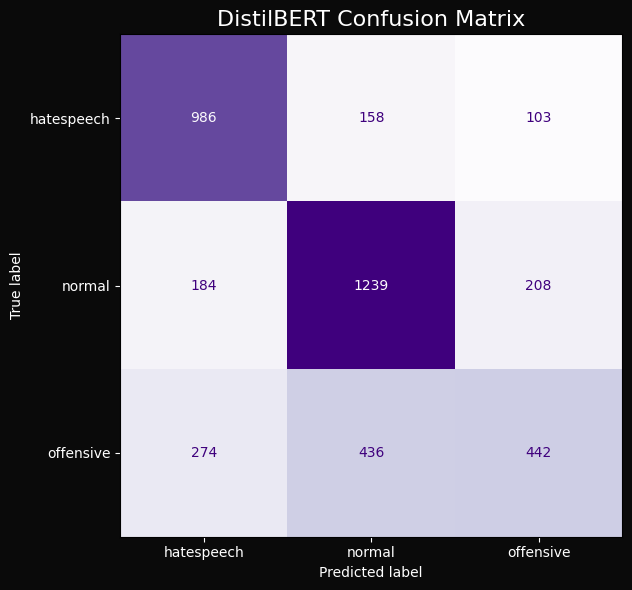

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6), facecolor="#0a0a0a")
ax.set_facecolor("#0a0a0a")

cm = confusion_matrix(y_test, y_pred_bert_labels, labels=["hatespeech", "normal", "offensive"])
disp = ConfusionMatrixDisplay(cm, display_labels=["hatespeech", "normal", "offensive"])
disp.plot(ax=ax, cmap="Purples", colorbar=False)

ax.set_title("DistilBERT Confusion Matrix", color="white", fontsize=16)
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.tick_params(colors="white")
plt.tight_layout()
plt.show()

**Confusion matrix shows the offensive class is the most confused**, split between hatespeech(274) and normal(436).

Also notable: 184 normal posts are falsely flagged as hate speech(false positives), raising concerns about unintended censorship.

# 7. Explainability Analysis: SHAP vs Human Rationales

In [ ]:
!pip install shap -q

import shap
from transformers import pipeline

#create prediction pipeline for SHAP
pipe = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0, top_k=None)

#take a small sample for SHAP (computationally expensive)
sample_texts = list(X_test[:100])

explainer = shap.Explainer(pipe)
shap_values = explainer(sample_texts[:20])

print("SHAP values computed!")

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   5%|▌         | 1/20 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  30%|███       | 6/20 [00:36<00:44,  3.16s/it]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  90%|█████████ | 18/20 [01:18<00:08,  4.16s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 21it [01:25,  4.29s/it]

SHAP values computed!


In [ ]:
#SHAP visualization for a hate speech example
#find a hatespeech example in our sample
for i in range(20):
    if y_test.iloc[i] == "hatespeech":
        print(f"Post {i}: {sample_texts[i][:100]}...")
        print(f"True label: {y_test.iloc[i]}")
        shap.plots.text(shap_values[i])
        break

Post 0: you lying nigger the kk did no such thing to your fam the niggers that got lynched were those who ra...
True label: hatespeech


**SHAP reveals the model relies almost entirely on the slur "nigger" for its hatespeech prediction**, pushing the score from a base value of 0.256 to 0.901.

This highlights an unintended bias risk: the model flags posts containing this word regardless of context.

Recall from EDA that "nawt yall niggers ignoring me" was labeled as "normal" by annotators, yet the model would likely classify it as hate speech based on keyword alone.

In [ ]:
#compare SHAP with human rationales
#find the same post in original data and get human rationales
test_indices = X_test.index[:20]

for i in range(20):
    if y_test.iloc[i] == "hatespeech":
        idx = test_indices[i]
        post_id = df.iloc[idx]["post_id"]

        #find in original data
        original = data[list(data.keys())[idx]]
        tokens = original["post_tokens"]
        rationales = original["rationales"]

        if len(rationales) > 0:
            #get human highlighted words (where any annotator marked 1)
            human_words = []
            for j, token in enumerate(tokens):
                for r in rationales:
                    if j < len(r) and r[j] == 1:
                        human_words.append(token)
                        break

            print(f"Post: {' '.join(tokens)[:100]}...")
            print(f"\nHuman rationale words: {list(set(human_words))}")
            print(f"\nSHAP top words: nigger, niggers (from visualization)")
            print(f"\nOverlap: Do model and humans look at the same words?")
        break

Post: you lying nigger the kk did no such thing to your fam the niggers that got lynched were those who ra...

Human rationale words: ['to', 'your', 'attempted', 'need', 'kill', 'who', 'got', 'go', 'did', 'the', 'fam', 'back', 'kk', 'whites', 'that', 'robbed', 'no', 'and', 'raped', 'niggers', 'africa', 'were', 'those', 'you', 'thing', 'lynched', 'nigger', 'such']

SHAP top words: nigger, niggers (from visualization)

Overlap: Do model and humans look at the same words?


**SHAP vs Human Rationale comparison:**

Humans highlighted 28 words across the full post, including contextual violence ("lynched", "raped", "kill", "go back to africa").

SHAP shows the model relies almost exclusively on the slur "nigger/niggers".

The model reaches the correct prediction but through a much narrower lens than humans.

This is a plausibility gap: right answer, incomplete reasoning.

# 8. Error Analysis

In [ ]:
#false positive example: normal post predicted as hatespeech
for i in range(len(y_test)):
    if y_test.iloc[i] == "normal" and y_pred_bert_labels[i] == "hatespeech":
        print(f"FALSE POSITIVE example:")
        print(f"Text: {X_test.iloc[i][:200]}")
        print(f"True: normal | Predicted: hatespeech")
        print()
        if i > 5:
            break

FALSE POSITIVE example:
Text: his father and uncle came to the uk in the number i was sexually assaulted by number paki muslim men in the number just walking down the street their wives and young children walking with them was tha
True: normal | Predicted: hatespeech



**False positive example:**

A personal testimony about sexual assault was flagged as hatespeech because it contains the slur "paki".

Annotators labeled it "normal" (personal account, not hate speech).

This demonstrates the model's over-reliance on keywords without understanding context.

In [ ]:
#error analysis summary
from collections import Counter

errors = []
for i in range(len(y_test)):
    true = y_test.iloc[i]
    pred = y_pred_bert_labels[i]
    if true != pred:
        errors.append(f"{true} → {pred}")

print(f"Total errors: {len(errors)}/{len(y_test)} ({len(errors)/len(y_test)*100:.1f}%)")
print(f"\nError breakdown:")
for error_type, count in Counter(errors).most_common():
    print(f"  {error_type}: {count}")

Total errors: 1363/4030 (33.8%)

Error breakdown:
  offensive → normal: 436
  offensive → hatespeech: 274
  normal → offensive: 208
  normal → hatespeech: 184
  hatespeech → normal: 158
  hatespeech → offensive: 103


**Error Analysis:**

33.8% of predictions are wrong.

The offensive class is the primary source of errors, confused with both normal(436) and hatespeech(274).

The most dangerous error is hatespeech → normal(158 missed hate speech posts).

This aligns with the annotation bias finding:

if humans can't agree on "offensive", the model can't learn it reliably either.

# 9. Conclusion

Accuracy alone is not sufficient for trustworthy hate speech detection.

DistilBERT achieves the best classification performance(66% accuracy, 0.64 macro-F1), but SHAP analysis reveals the model relies on narrow keyword patterns rather than contextual reasoning.

The comparison between SHAP explanations and human rationales exposes a plausibility gap: the model often gets the right answer for incomplete reasons. Bias analysis further highlights structural challenges: high annotator disagreement(51.1%), platform sampling bias, and target community imbalance.



**Limitations:**

- English only,
- No external context,
- Single explainability method.



**Future Work:**

- Integrated Gradients,
- Multilingual detection,
- Context-aware models.